# 004 — PSHA results: hazard curves

Post-processes the six WP1 PSHA calculations set up and run by `003-psha_setup_and_analyses.ipynb`
(**AvgSA 0–3** and **AvgSA 0–6**, each at GMM truncation level **3, 4 and 5 sigma**) into
hazard curves for the 60 selected sites.

1. Resolves the OpenQuake `calc_id` of each analysis from `wp1/psha_manifest.json` — no
   hardcoded integers.
2. Extracts the hazard curves from each datastore into one flat dictionary per analysis,
   in **mean annual frequency of exceedance (MAFE)**, or reloads them from the pickles
   where the datastore is not reachable (`SOURCE`).
3. Saves the six dictionaries as pickles suffixed `_3sig`, `_4sig`, `_5sig`.
4. Plots the hazard curves by region, contrasting **high** and **low/moderate** seismicity sites.
5. Plots the effect of the **GMM truncation level** on the individual site curves.
6. Fits the **first and second order approximations** to the 4σ AvgSA 0–3 curves and saves
   the `k0` / `k1` / `k2` parameters as two CSVs.

## Prerequisites

`003-psha_setup_and_analyses.ipynb` must have been run with `DRY_RUN = False`, so that:

- all six entries exist in `hazard_models/eshm20/wp1/psha_manifest.json`, and
- the corresponding OpenQuake datastores (`calc_<id>.hdf5`) are present in the local
  `oqdata` directory.

The datastores are **machine-local and not tracked** (they are large and rebuildable). The
manifest is the git-tracked pointer that makes them reproducible — if the datastores are
missing, re-run `003` rather than editing calc ids here.

To re-run only the plots and fits without the datastores, `dvc pull` the six pickles and
leave `SOURCE = "auto"` (or force `SOURCE = "pickle"`). Sections 3–6 need nothing else:
everything downstream reads `hcs`, not the datastores.

## Dependencies

**Upstream:** `001-site_selection.ipynb` → `results/01_site_selection/sites.csv` (the site
register, and the source of the `seismicity` / `region` grouping used in the plots);
`003-psha_setup_and_analyses.ipynb` → `wp1/psha_manifest.json` and `wp1/site_model_all_sites.csv`.

**Downstream:** `017-disagg_imls_for_msa_stripes.ipynb` consumes the `_3sig` / `_4sig` /
`_5sig` pickles written here to pick the MSA stripe IMLs. The fit CSVs feed the closed-form
SAC/FEMA solutions in `hazrisk.risk`.

## Outputs

Six pickles in `data_processed/03_site_hazard` (**DVC-tracked**, like the rest of that folder):

```
AvgSA_03_hazard_curves_60sites_{3,4,5}sig.pickle
AvgSA_06_hazard_curves_60sites_{3,4,5}sig.pickle
```

All six share **one** structure — the raw `get_hcurves_from_dstore` shape:

```
hcs[site_id][imt][stat] -> np.ndarray, shape (n_iml, 2)
                           column 0 = IML [g]
                           column 1 = MAFE [1/yr]
```

`site_id` is the positional row index of `sites.csv` (0–59). There is no
`(seismicity, region)` grouping level and no `"mean_site"` key — grouping is applied at
plot time from `sites.csv`, so the artifacts stay flat and uniform.

Plus two hazard-approximation CSVs in the same folder, one row per site (**git-tracked**,
they are small and text):

```
AvgSA_03_hazard_fit_first_order_60sites_4sig.csv    site_id, seismicity, region,
                                                    k0, k1, rtp_low, rtp_high
AvgSA_03_hazard_fit_second_order_60sites_4sig.csv   site_id, seismicity, region,
                                                    k0, k1, k2, r2, n_points,
                                                    rtp_low, rtp_high
```

`rtp_low` / `rtp_high` are the return periods each fit was actually made over.

In [24]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 0. Setup & parameters

In [25]:
import string
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.lines as mlines

from openquake.commonlib.datastore import read

from hazrisk import hazard as haz

from phd_project.config import config
from phd_project.plotting.plotting import custom_log_formatter
from phd_project.scripts.oqhelpers import get_hcurves_from_dstore
from phd_project.scripts import oq_runner
from phd_project.scripts.hazard import get_mask

cfg = config.load_config()

In [26]:
# -----------------------------------------------------------------------------
# PARAMETERS
# -----------------------------------------------------------------------------
# IM definition -> axis label. The key is the prefix of both the manifest entry
# name and the output pickle name.
IMS = {"AvgSA_03": "AvgSA[0,3]", "AvgSA_06": "AvgSA[0,6]"}

# GMM truncation level: manifest suffix -> output-filename suffix.
TRUNCS = {"eps3": "3sig", "eps4": "4sig", "eps5": "5sig"}

IMT = "AvgSA"   # the single IMT present in these calculations
STAT = "mean"   # the OpenQuake statistic plotted (the pickles keep all of them)

N_SITES = 60
REGIONS = list(range(6))
SEISMICITIES = ("high", "lowmod")

HAZ_DIR = cfg["proc_data"]["site_hazard"]
MANIFEST_FP = cfg["hazard_models"]["eshm20_wp1_psha_manifest"]
SITES_FP = cfg["results"]["selected_sites_csv"]
SITE_MODEL_FP = cfg["hazard_models"]["eshm20_wp1_site_model"]

# SOURCE: where the hazard curves come from.
#   "datastore" - extract from the OpenQuake datastores; fail if they are missing.
#   "pickle"    - reload the pickles a previous run wrote, ignoring the datastores.
#   "auto"      - datastore where it can be read, pickle where it cannot.
# The datastores are machine-local, so "auto" is what makes the rest of the
# notebook runnable anywhere the DVC-tracked pickles have been pulled.
SOURCE = "auto"

# SAVE: write the pickles. False = extract and plot only, touching nothing on disk.
# Only curves read from a datastore are written back; a pickle is never re-pickled.
SAVE = True
# -----------------------------------------------------------------------------

assert SOURCE in ("datastore", "pickle", "auto"), f"unknown SOURCE {SOURCE!r}"

print(f"hazard dir: {HAZ_DIR}")
print(f"manifest:   {MANIFEST_FP}")
print(f"analyses:   {len(IMS) * len(TRUNCS)} "
      f"({sorted(IMS)} x {sorted(TRUNCS)})")
print(f"SOURCE={SOURCE}, SAVE={SAVE}")

hazard dir: C:\Users\clemettn\Documents\phd\data_processed\03_site_hazard
manifest:   C:\Users\clemettn\Documents\phd\hazard_models\eshm20\wp1\psha_manifest.json
analyses:   6 (['AvgSA_03', 'AvgSA_06'] x ['eps3', 'eps4', 'eps5'])
SOURCE=auto, SAVE=True


## 1. Sites & calculation ids

`sites.csv` and `wp1/site_model_all_sites.csv` are row-aligned by construction (`003`
writes the latter from the former), so they can be joined positionally. The resulting
index **is** the site id used everywhere in this project.

The two grouping keys come from `sites.csv`: `seismicity` (`"high"` / `"lowmod"`) and
`region` (`0`–`5`) — 5 sites in each of the 12 combinations.

In [27]:
sel_sites = pd.read_csv(SITES_FP)
site_model = pd.read_csv(SITE_MODEL_FP)
site_metadata = pd.concat([sel_sites, site_model], axis=1).T.drop_duplicates().T

assert len(site_metadata) == N_SITES, (
    f"expected {N_SITES} sites, got {len(site_metadata)} — "
    f"check {SITES_FP} and {SITE_MODEL_FP} are the same 60 rows in the same order")

print(site_metadata.groupby(["seismicity", "region"]).size().to_string())

seismicity  region
high        0         5
            1         5
            2         5
            3         5
            4         5
            5         5
lowmod      0         5
            1         5
            2         5
            3         5
            4         5
            5         5


In [28]:
calc_ids = oq_runner.load_calc_ids(MANIFEST_FP) if MANIFEST_FP.exists() else {}

expected = [f"{im}_psha_{eps}" for im in IMS for eps in TRUNCS]
missing = [name for name in expected if name not in calc_ids]

# The manifest is only needed to reach the datastores. Running from the pickles
# does not need it, so a missing entry is only fatal when SOURCE demands one.
assert not (missing and SOURCE == "datastore"), (
    f"missing from {MANIFEST_FP}: {missing} — re-run 003 with DRY_RUN = False, "
    f"or set SOURCE = 'pickle'")

if missing:
    print(f"no calc id for: {missing} — these will be read from their pickles\n")

for name in expected:
    if name in calc_ids:
        print(f"{name:24s} calc_id = {calc_ids[name]}")

AvgSA_03_psha_eps3       calc_id = 28
AvgSA_03_psha_eps4       calc_id = 29
AvgSA_03_psha_eps5       calc_id = 30
AvgSA_06_psha_eps3       calc_id = 31
AvgSA_06_psha_eps4       calc_id = 32
AvgSA_06_psha_eps5       calc_id = 33


## 2. Extract & save hazard curves

One pass over the six analyses. `get_hcurves_from_dstore` converts the OpenQuake
probability of exceedance to MAFE (`-ln(1 - poe) / investigation_time`), so the curves are
in MAFE as stored.

The datastores are machine-local, so each analysis has two possible sources: its OpenQuake
datastore, or the pickle a previous run wrote to `data_processed/03_site_hazard`. `SOURCE`
picks between them — `"auto"` (the default) tries the datastore and falls back to the
pickle per analysis, so the notebook runs anywhere the DVC-tracked pickles have been
pulled, without `003` having been run on this machine. Only curves that came from a
datastore are written back.


In [29]:
def curves_from_datastore(im, eps):
    """Extract one analysis' hazard curves from its OpenQuake datastore."""
    dstore = read(calc_ids[f"{im}_psha_{eps}"])
    return get_hcurves_from_dstore(dstore, mafe=True)


def curves_from_pickle(im, sig):
    """Reload one analysis' hazard curves from the pickle a previous run wrote."""
    with open(HAZ_DIR / f"{im}_hazard_curves_60sites_{sig}.pickle", "rb") as f:
        return pickle.load(f)


hcs = {}       # hcs[(im, sig)] -> hazard curves for one analysis
sources = {}   # hcs key -> where those curves actually came from

for im in IMS:
    for eps, sig in TRUNCS.items():
        source = "pickle"

        if SOURCE in ("datastore", "auto"):
            try:
                curves = curves_from_datastore(im, eps)
                source = "datastore"
            # openquake signals a missing calculation with several unrelated
            # types (dbapi.NotFound, FileNotFoundError, h5py OSError), none of
            # which share a base class, so the fallback catches broadly.
            except Exception as exc:
                if SOURCE == "datastore":
                    raise
                print(f"{im}/{eps}: datastore unavailable "
                      f"({type(exc).__name__}: {exc}) — reading the pickle instead")

        if source == "pickle":
            curves = curves_from_pickle(im, sig)

        assert len(curves) == N_SITES, (
            f"{im}/{eps}: {source} has {len(curves)} sites, expected {N_SITES}")
        hcs[(im, sig)] = curves
        sources[(im, sig)] = source

        # Only what was just extracted is written back — re-pickling a pickle
        # would rewrite the file (and dirty DVC) for no gain.
        if SAVE and source == "datastore":
            fp = HAZ_DIR / f"{im}_hazard_curves_60sites_{sig}.pickle"
            with open(fp, "wb") as f:
                pickle.dump(curves, f)
            print(f"wrote {fp.name}")

n_dstore = sum(s == "datastore" for s in sources.values())
print(f"\n{len(hcs)} analyses loaded — {n_dstore} from openquake, "
      f"{len(hcs) - n_dstore} from pickles.")

AvgSA_03/eps3: datastore unavailable (NotFound: calc_id=28 missing in the database) — reading the pickle instead
AvgSA_03/eps4: datastore unavailable (NotFound: calc_id=29 missing in the database) — reading the pickle instead
AvgSA_03/eps5: datastore unavailable (NotFound: calc_id=30 missing in the database) — reading the pickle instead
AvgSA_06/eps3: datastore unavailable (NotFound: calc_id=31 missing in the database) — reading the pickle instead
AvgSA_06/eps4: datastore unavailable (NotFound: calc_id=32 missing in the database) — reading the pickle instead
AvgSA_06/eps5: datastore unavailable (NotFound: calc_id=33 missing in the database) — reading the pickle instead

6 analyses loaded — 0 from openquake, 6 from pickles.


In [30]:
# Structure check: every analysis must have the same flat, MAFE shape.
for (im, sig), curves in hcs.items():
    assert sorted(curves) == list(range(N_SITES)), f"{im}/{sig}: site keys are not 0..{N_SITES-1}"
    assert IMT in curves[0], f"{im}/{sig}: IMT {IMT!r} not in {list(curves[0])}"
    assert STAT in curves[0][IMT], f"{im}/{sig}: stat {STAT!r} not in {list(curves[0][IMT])}"

    hc = curves[0][IMT][STAT]
    assert hc.ndim == 2 and hc.shape[1] == 2, f"{im}/{sig}: curve shape {hc.shape}, expected (n, 2)"
    assert (np.diff(hc[:, 1]) <= 0).all(), f"{im}/{sig}: MAFE column is not decreasing"

print(f"OK — {len(hcs)} x hcs[site_id][{IMT!r}][stat] -> (n_iml, 2), "
      f"col 1 = MAFE, stats = {list(hcs[('AvgSA_03', '3sig')][0][IMT])}")

OK — 6 x hcs[site_id]['AvgSA'][stat] -> (n_iml, 2), col 1 = MAFE, stats = ['mean', 'quantile-0.16', 'quantile-0.5', 'quantile-0.84']


## 3. Plotting constants & helpers

The flat structure carries no group means, so the group mean is computed at plot time.
It is the same quantity the old grouped pickles stored: the mean over the **MAFE column**
of the sites in a group, against the shared IML column.

In [31]:
legend_font_params = {'size': 9}
legend_title_font_params = {'weight': 'bold', 'size': 9}

# hazard curve plots (high vs low/mod)
hc_labels = ["High site", "Low/mod site", "Mean - high sites", "Mean - low/mod sites"]
hc_colours = ["r", "g", "r", "g"]
hc_line_styles = ["-", "-", "--", "--"]
hc_alphas = [0.3, 0.3, 1.0, 1.0]

# truncation level comparison: colour = site slot within a region, style = truncation
site_colours = ["C0", "C1", "C2", "C3", "C4"]
trunc_line_styles = {"3sig": "-", "4sig": "--", "5sig": ":"}

# hazard curve approximations: colour = site slot within a region, style = curve
fit_line_styles = {"Numerical": "-", "1st order": "--", "2nd order": ":"}

seismicity_labels = {"high": "High seismicity", "lowmod": "Low/moderate seismicity"}

In [32]:
def group_site_ids(metadata, seismicity, region):
    """Site ids belonging to one (seismicity, region) group, in site-id order."""
    mask = get_mask(["seismicity", "region"], [seismicity, region], metadata)
    return sorted(metadata[mask].index.tolist())


def mean_curve(curves, site_ids, imt=IMT, stat=STAT):
    """Mean hazard curve over `site_ids` -> ndarray (n_iml, 2).

    The IMLs are identical across sites within a calculation, so only the MAFE
    column is averaged.
    """
    imls = curves[site_ids[0]][imt][stat][:, 0]
    mafes = np.vstack([curves[i][imt][stat][:, 1] for i in site_ids])
    return np.vstack([imls, mafes.mean(axis=0)]).T


def style_hc_axis(ax, panel_idx, region):
    """The shared hazard-curve axis furniture."""
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(custom_log_formatter))
    ax.set_xlim(0.001, 5)
    ax.set_ylim(1e-6, 1)

    ax.grid(True, which="both", ls="-.", color="0.8")
    ax.minorticks_on()
    ax.tick_params(axis='y', which='minor', left=False)

    ax.text(0.0011, 1.5e-6, f"({string.ascii_uppercase[panel_idx]})")
    ax.text(0.5, 2e-1, f"Region {region}")

## 4. Hazard curves by region — high vs low/moderate seismicity

One figure per (IM definition × truncation level). Faint solid lines are individual sites,
dashed lines the group mean; red is high seismicity, green low/moderate.

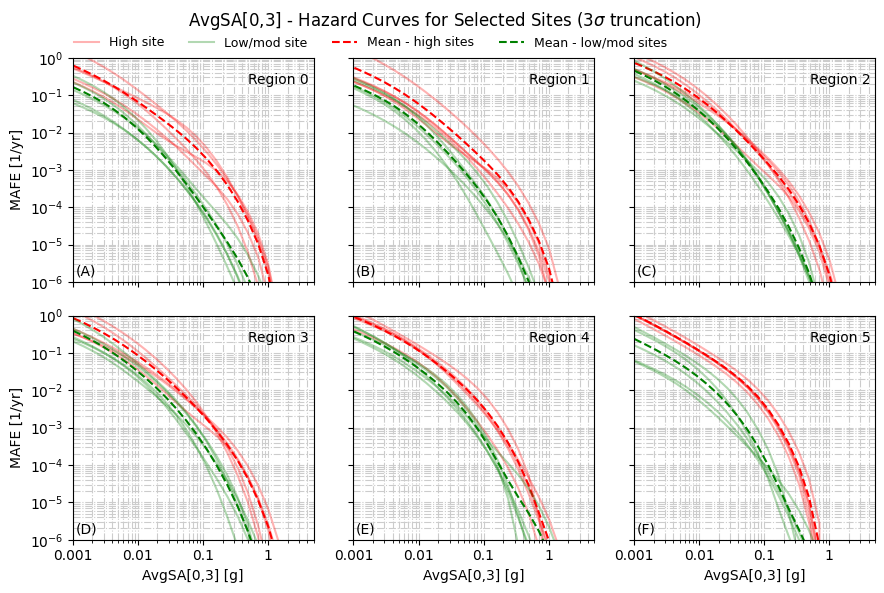

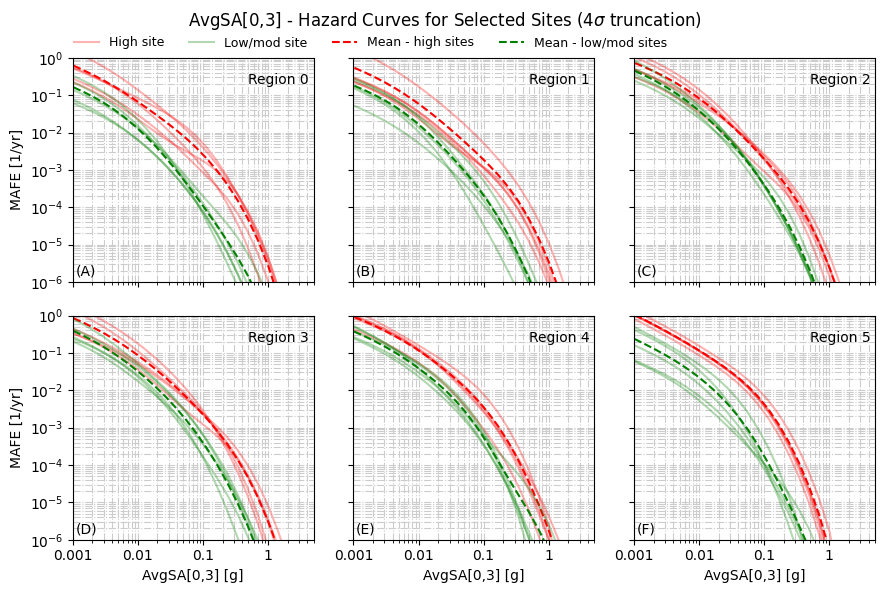

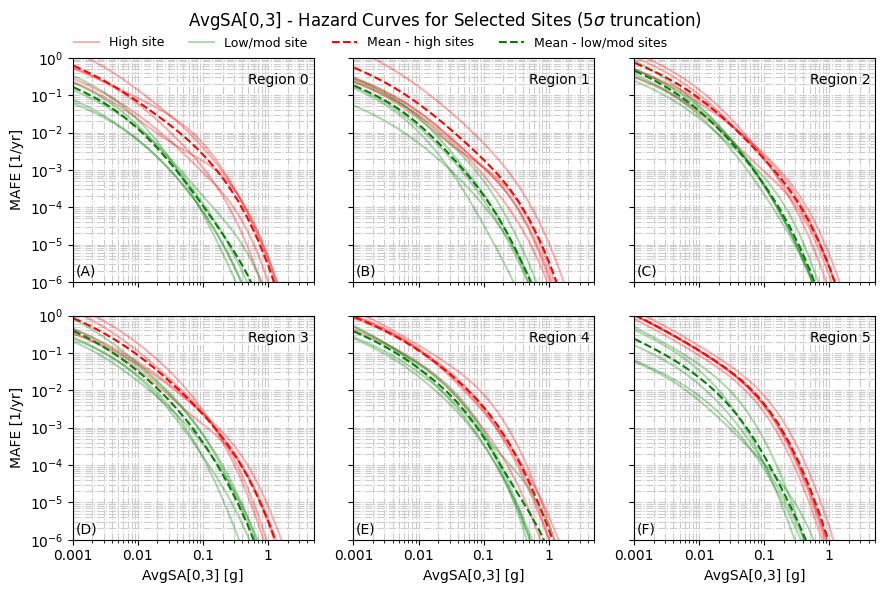

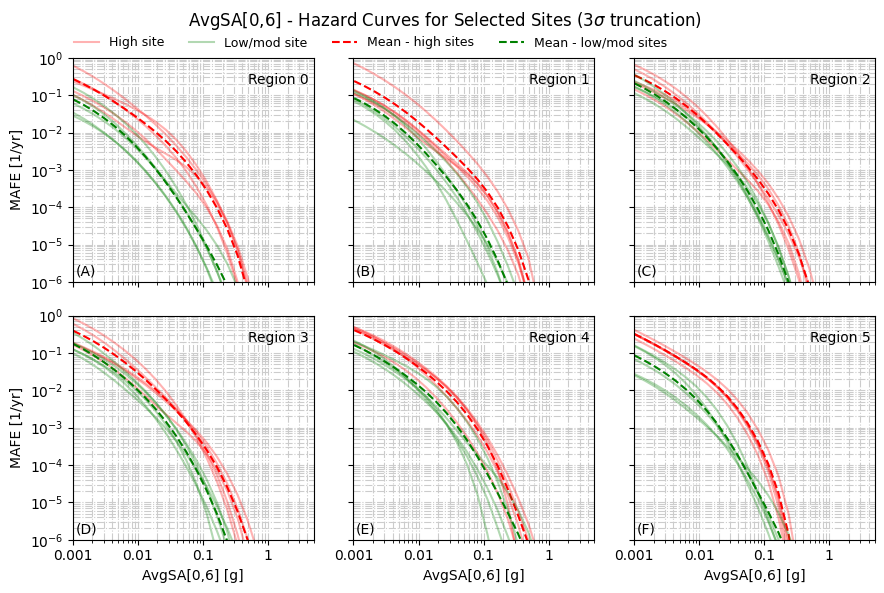

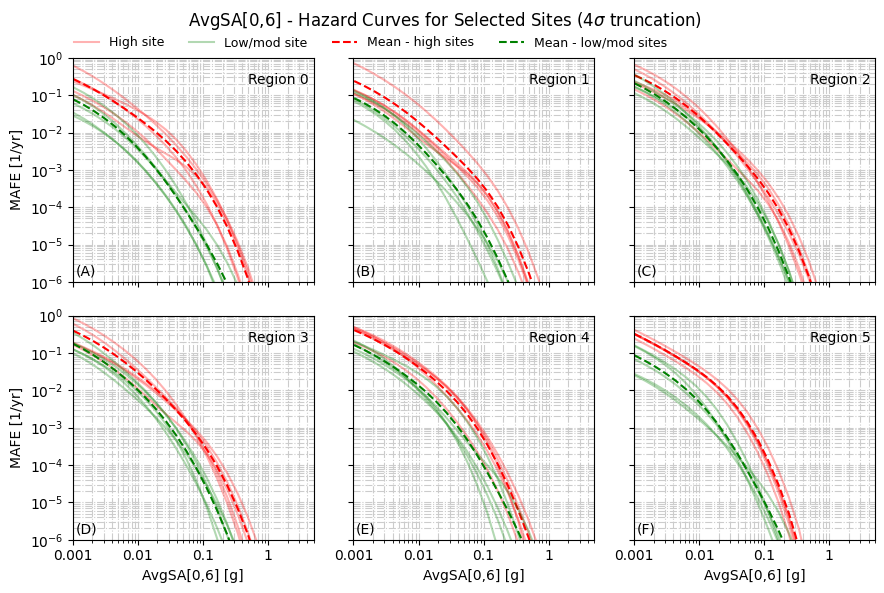

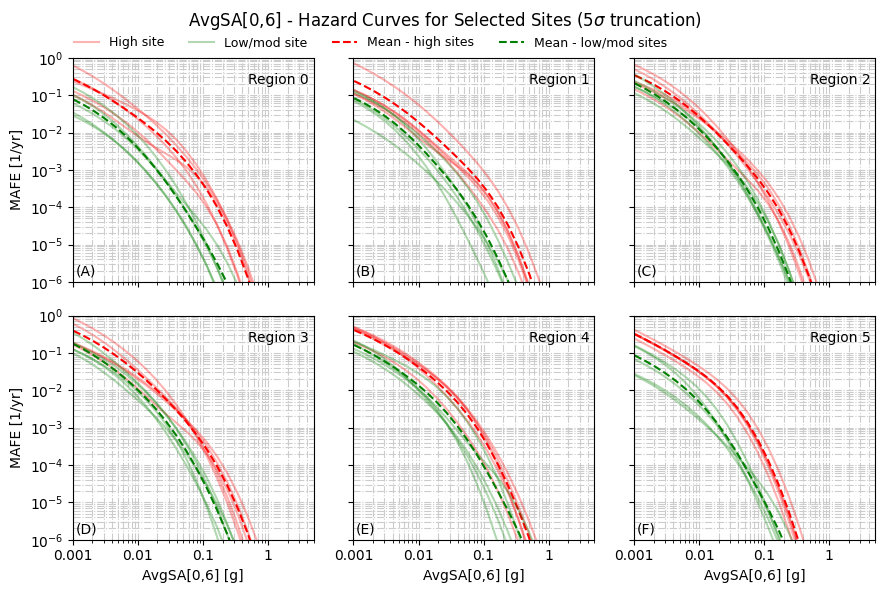

In [33]:
for im, im_label in IMS.items():
    for sig in TRUNCS.values():
        curves = hcs[(im, sig)]

        fig, axs = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(9, 6))

        for ii, (r, ax) in enumerate(zip(REGIONS, axs.flatten())):
            for s in SEISMICITIES:
                color = "r" if s == "high" else "g"
                site_ids = group_site_ids(site_metadata, s, r)

                for site_id in site_ids:
                    hc = curves[site_id][IMT][STAT]
                    ax.loglog(hc[:, 0], hc[:, 1], ls="-", color=color, alpha=0.3)

                hc = mean_curve(curves, site_ids)
                ax.loglog(hc[:, 0], hc[:, 1], ls="--", color=color)

            style_hc_axis(ax, ii, r)

        axs[0, 0].set_ylabel("MAFE [1/yr]")
        axs[1, 0].set_ylabel("MAFE [1/yr]")
        for ax in axs[1, :]:
            ax.set_xlabel(f"{im_label} [g]")

        handles = [
            mlines.Line2D([], [], color=c, label=l, linestyle=ls, alpha=a)
            for c, l, ls, a in zip(hc_colours, hc_labels, hc_line_styles, hc_alphas)
        ]

        leg = fig.legend(handles=handles,
                         ncols=4,
                         loc="upper left",
                         bbox_to_anchor=(0.075, 0.955),
                         prop=legend_font_params,
                         frameon=False)
        leg._legend_box.align = "left"

        fig.suptitle(f"{im_label} - Hazard Curves for Selected Sites "
                     f"({sig[0]}$\\sigma$ truncation)")
        fig.tight_layout()

## 5. Effect of the GMM truncation level

One figure per (IM definition × seismicity class). Within each region panel the same five
sites are drawn at all three truncation levels: **colour** identifies the site's slot
within its region, **line style** the truncation level.

The truncation level sets a ceiling on the ground motion the GMM will produce, which is
what makes each curve fall away at its right-hand end. Raising it extends the curve into
rarer, larger ground motions.

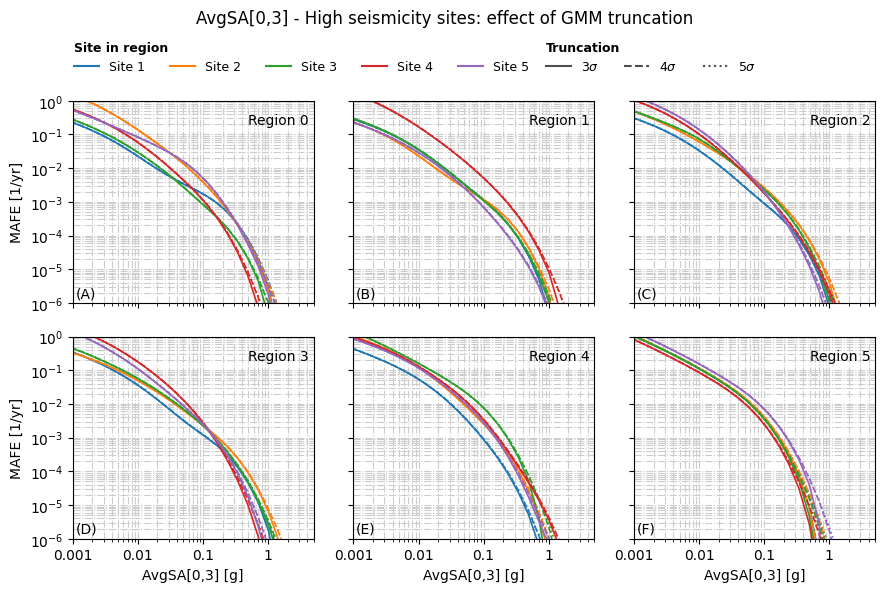

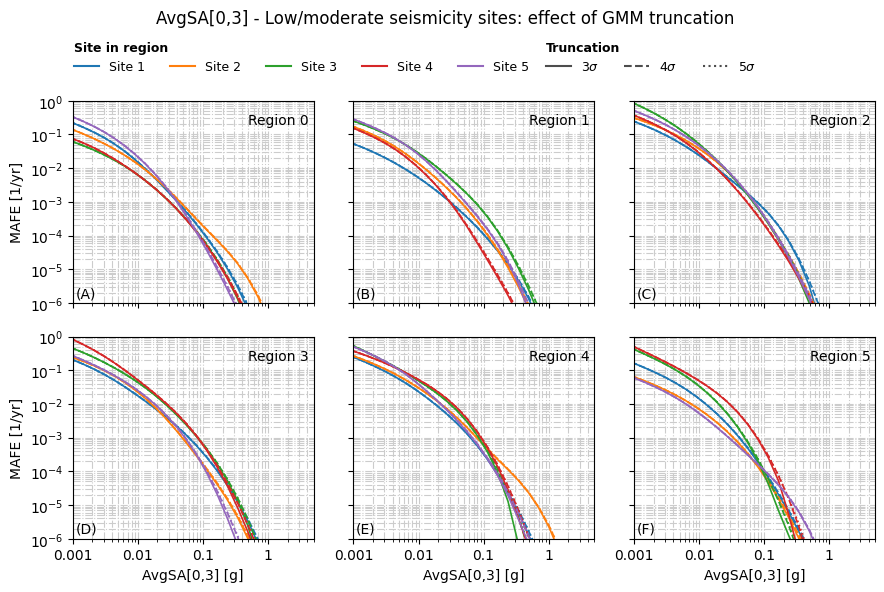

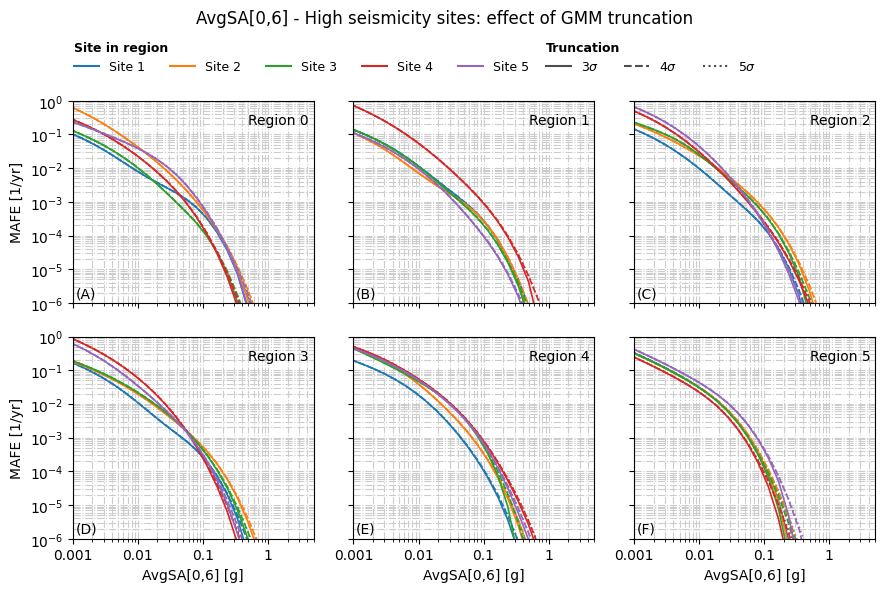

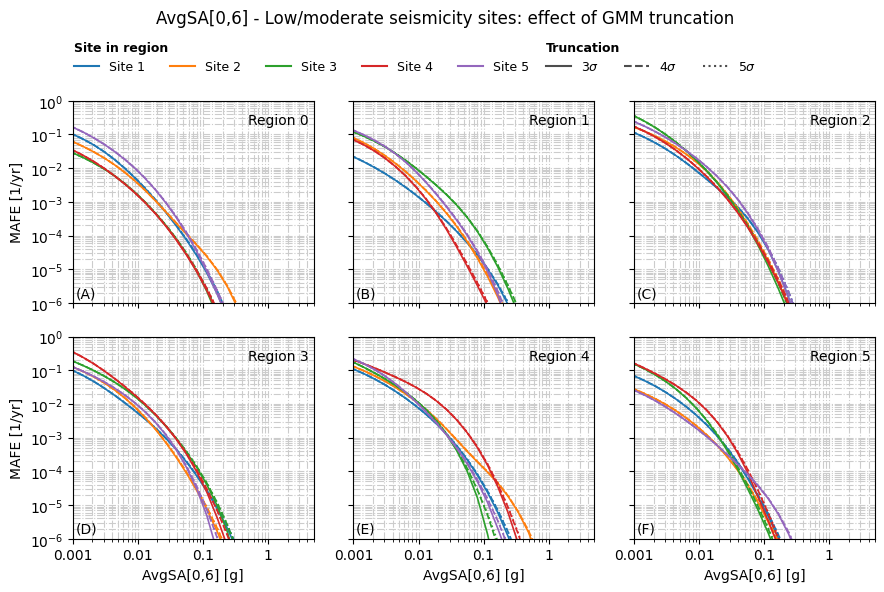

In [34]:
for im, im_label in IMS.items():
    for s in SEISMICITIES:

        fig, axs = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(9, 6))

        for ii, (r, ax) in enumerate(zip(REGIONS, axs.flatten())):
            site_ids = group_site_ids(site_metadata, s, r)

            for j, site_id in enumerate(site_ids):
                for sig in TRUNCS.values():
                    hc = hcs[(im, sig)][site_id][IMT][STAT]
                    ax.loglog(hc[:, 0], hc[:, 1],
                              color=site_colours[j],
                              ls=trunc_line_styles[sig],
                              lw=1.2)

            style_hc_axis(ax, ii, r)

        axs[0, 0].set_ylabel("MAFE [1/yr]")
        axs[1, 0].set_ylabel("MAFE [1/yr]")
        for ax in axs[1, :]:
            ax.set_xlabel(f"{im_label} [g]")

        site_handles = [
            mlines.Line2D([], [], color=c, label=f"Site {j + 1}")
            for j, c in enumerate(site_colours)
        ]
        trunc_handles = [
            mlines.Line2D([], [], color="0.3", ls=ls, label=f"{sig[0]}$\\sigma$")
            for sig, ls in trunc_line_styles.items()
        ]

        leg1 = fig.legend(handles=site_handles, title="Site in region",
                          ncols=5, loc="upper left", bbox_to_anchor=(0.075, 0.945),
                          prop=legend_font_params,
                          title_fontproperties=legend_title_font_params,
                          frameon=False)
        leg1._legend_box.align = "left"

        leg2 = fig.legend(handles=trunc_handles, title="Truncation",
                          ncols=3, loc="upper left", bbox_to_anchor=(0.60, 0.945),
                          prop=legend_font_params,
                          title_fontproperties=legend_title_font_params,
                          frameon=False)
        leg2._legend_box.align = "left"

        fig.suptitle(f"{im_label} - {seismicity_labels[s]} sites: "
                     f"effect of GMM truncation")
        fig.tight_layout(rect=(0, 0, 1, 0.92))

## 6. Approximation of Hazard Curves

The SAC/FEMA closed-form risk solutions in `hazrisk.risk` do not take a numerical hazard
curve — they take its **first order** (Cornell et al. 2002) or **second order**
(Vamvatsikos 2013) approximation:

```
first order:   H(im) = k0 * im ** (-k1)
second order:  H(im) = k0 * exp(-k2 * ln(im)**2 - k1 * ln(im))
```

This section reduces each of the 60 **4σ AvgSA[0,3]** curves to those parameters, using the
fitters in `hazrisk.hazard`. AvgSA[0,6] is not fitted.

- **First order** — `fit_first_order_points`, anchored through the **475** and **2475 yr**
  return periods. Two points define the log-log line exactly, and the fitted curve passes
  through both; points that do not land on a value of the numerical curve are interpolated
  in log-log space.
- **Second order** — `fit_second_order_regression`, least squares over the
  **10–10 000 yr** band. A three-point fit is not usable here: the AvgSA calculations carry
  only 25 IMLs, and the 475–2475 yr window holds too few of them. The wider band gives
  8–15 points per site.

The band is **clamped to each site's own curve**: where the curve does not reach 10 yr (its
MAFE tops out just under 0.1) or does not reach 10 000 yr, the nearest available return
period is used instead. `rtp_low` / `rtp_high` in the output record what was actually
fitted, so the range of validity travels with the parameters.

The raw curves underflow to zero at the rare end, so they are trimmed to the strictly
positive, strictly decreasing portion the fitters require.

In [35]:
# -----------------------------------------------------------------------------
# FIT PARAMETERS
# -----------------------------------------------------------------------------
FIT_IM = "AvgSA_03"        # only the 0-3 s definition is fitted
FIT_SIG = "4sig"           # only the 4 sigma truncation is fitted

FO_RTP = (475, 2475)       # first order: the two anchor return periods [yr]
SO_RTP_BAND = (10, 10000)  # second order: the regression band [yr]
# -----------------------------------------------------------------------------


def trim_curve(hc):
    """Numerical curve -> (im, H_im), trimmed to what the fitters accept.

    `_validate_curve` requires strictly positive, strictly decreasing MAFE, but the
    raw curves underflow to zero at the rare end (hence the non-strict assertion in
    section 2). Drop the zero tail, then stop at the first non-decreasing step.
    """
    im, H_im = hc.T

    keep = H_im > 0
    im, H_im = im[keep], H_im[keep]

    decreasing = np.concatenate([[True], np.diff(H_im) < 0])
    stop = np.argmin(decreasing) if not decreasing.all() else len(im)
    return im[:stop], H_im[:stop]


def clamped_mafe_band(H_im, rtp_band=SO_RTP_BAND):
    """`(low, high)` MAFE band of `rtp_band`, clamped to the curve's own range.

    Where the curve does not reach the requested return period - either end - the
    nearest return period the curve does carry is used instead.
    """
    low, high = sorted(rtp_band)
    return max(1 / high, float(H_im.min())), min(1 / low, float(H_im.max()))


curves = hcs[(FIT_IM, FIT_SIG)]
fo_records, so_records = [], []

for site_id in sorted(curves):
    im, H_im = trim_curve(curves[site_id][IMT][STAT])
    meta = {"site_id": site_id,
            "seismicity": site_metadata.loc[site_id, "seismicity"],
            "region": site_metadata.loc[site_id, "region"]}

    k0, k1 = haz.fit_first_order_points(im, H_im, mafe=[1 / rtp for rtp in FO_RTP])
    fo_records.append({**meta, "k0": k0, "k1": k1,
                       "rtp_low": min(FO_RTP), "rtp_high": max(FO_RTP)})

    band = clamped_mafe_band(H_im)
    k0, k1, k2, r2 = haz.fit_second_order_regression(im, H_im, mafe_band=band)
    n_points = int(((H_im >= band[0]) & (H_im <= band[1])).sum())
    so_records.append({**meta, "k0": k0, "k1": k1, "k2": k2, "r2": r2,
                       "n_points": n_points,
                       "rtp_low": 1 / band[1], "rtp_high": 1 / band[0]})

fits_fo = pd.DataFrame(fo_records)
fits_so = pd.DataFrame(so_records)

if SAVE:
    for order, df in (("first_order", fits_fo), ("second_order", fits_so)):
        fp = HAZ_DIR / f"{FIT_IM}_hazard_fit_{order}_60sites_{FIT_SIG}.csv"
        df.to_csv(fp, index=False)
        print(f"wrote {fp.name}")

print(f"\nsecond order r2: min {fits_so['r2'].min():.4f}, "
      f"points per fit {fits_so['n_points'].min()}-{fits_so['n_points'].max()}")

clamped = fits_so[(fits_so["rtp_low"] > min(SO_RTP_BAND) * 1.001)
                  | (fits_so["rtp_high"] < max(SO_RTP_BAND) * 0.999)]
print(f"{len(clamped)} of {len(fits_so)} second order bands clamped to the curve "
      f"(actual span {fits_so['rtp_low'].max():.0f}-{fits_so['rtp_high'].min():.0f} yr "
      f"at worst)")

display(fits_fo.head())
display(fits_so.head())

wrote AvgSA_03_hazard_fit_first_order_60sites_4sig.csv
wrote AvgSA_03_hazard_fit_second_order_60sites_4sig.csv

second order r2: min 0.9955, points per fit 8-15
3 of 60 second order bands clamped to the curve (actual span 12-10000 yr at worst)


,site_id,seismicity,region,k0,k1,rtp_low,rtp_high
0,0,lowmod,0,9.846309e-07,2.159963,475,2475
1,1,lowmod,0,2.093277e-06,1.983694,475,2475
2,2,lowmod,0,1.314235e-06,1.895789,475,2475
3,3,lowmod,0,1.262325e-06,1.906187,475,2475
4,4,lowmod,0,1.625747e-07,2.709265,475,2475


,site_id,seismicity,region,k0,k1,k2,r2,n_points,rtp_low,rtp_high
0,0,lowmod,0,1.438767e-07,3.370612,0.186733,0.999931,10,10.000000,10000.0
1,1,lowmod,0,4.491554e-07,3.049090,0.177688,0.999846,12,10.000000,10000.0
2,2,lowmod,0,1.858223e-07,3.091187,0.180618,0.999570,15,10.561645,10000.0
3,3,lowmod,0,1.688055e-07,3.102785,0.176855,0.999784,14,10.000000,10000.0
4,4,lowmod,0,5.435491e-09,4.860457,0.337370,0.999976,9,10.000000,10000.0


### Fitted vs numerical curves

The same 2×3 layout as section 5: one figure per seismicity class, one panel per region,
**colour** identifies the site's slot within its region and **line style** the curve. The
numerical curve is the wide faint solid line; the fits are drawn over it, dashed for first
order and dotted for second order.

Both approximations are **extrapolated across the full range of the numerical curve**, not
just the return periods they were fitted to, so the panels show where each one departs from
the data as well as where it tracks it. The first order power law is anchored on 475–2475 yr
and fans away from the curve on both sides of that window; the second order fit was
regressed over 10–10 000 yr and holds over most of the range. Where the fitted parabola
turns over (at `ln(im) = -k1 / (2 * k2)`) the second order curve bends back down — an
artefact of the form, and a reminder that neither fit should be used outside `rtp_low` to
`rtp_high`.


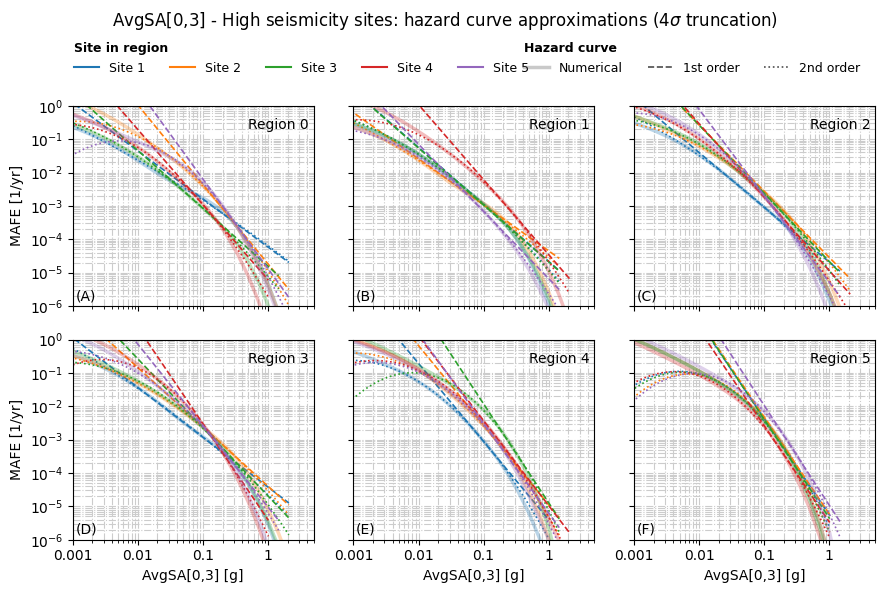

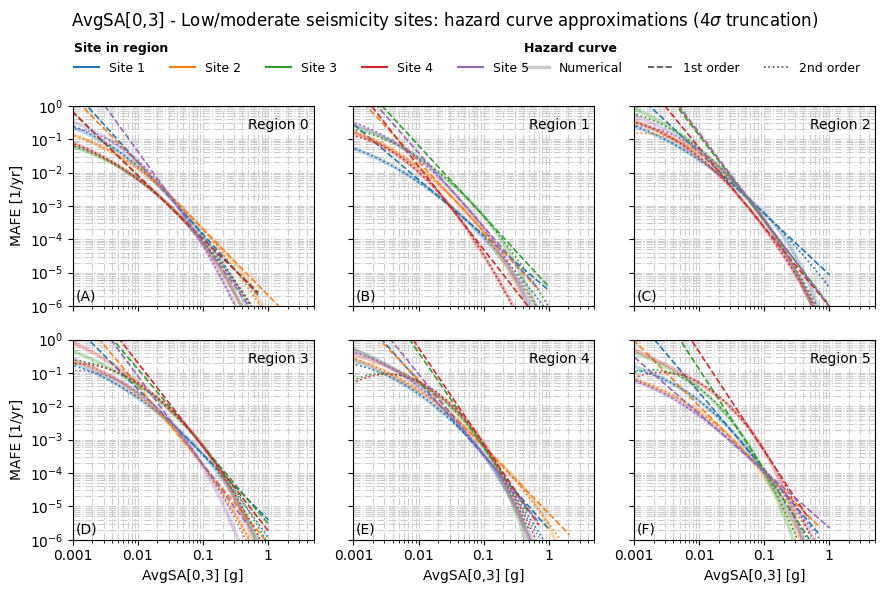

In [36]:
fo_by_site = fits_fo.set_index("site_id")
so_by_site = fits_so.set_index("site_id")


def data_span(im, n=300):
    """Log-spaced IMLs over the full range of the numerical curve."""
    return np.logspace(np.log10(im[0]), np.log10(im[-1]), n)


for s in SEISMICITIES:

    fig, axs = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(9, 6))

    for ii, (r, ax) in enumerate(zip(REGIONS, axs.flatten())):
        site_ids = group_site_ids(site_metadata, s, r)

        for j, site_id in enumerate(site_ids):
            # the numerical curve is drawn wide and faint so the fits, which sit
            # almost on top of it, stay legible against it
            im, H_im = trim_curve(curves[site_id][IMT][STAT])
            ax.loglog(im, H_im, color=site_colours[j],
                      ls=fit_line_styles["Numerical"], lw=2.5, alpha=0.3)

            # both fits are extrapolated across the full range of the data, so
            # the panels show how each one behaves outside the range it was
            # fitted to as well as inside it
            x = data_span(im)

            fo = fo_by_site.loc[site_id]
            ax.loglog(x, haz.first_order_approx(x, fo.k0, fo.k1),
                      color=site_colours[j], ls=fit_line_styles["1st order"], lw=1.2)

            so = so_by_site.loc[site_id]
            ax.loglog(x, haz.second_order_approx(x, so.k0, so.k1, so.k2),
                      color=site_colours[j], ls=fit_line_styles["2nd order"], lw=1.2)

        style_hc_axis(ax, ii, r)

    axs[0, 0].set_ylabel("MAFE [1/yr]")
    axs[1, 0].set_ylabel("MAFE [1/yr]")
    for ax in axs[1, :]:
        ax.set_xlabel(f"{IMS[FIT_IM]} [g]")

    site_handles = [
        mlines.Line2D([], [], color=c, label=f"Site {j + 1}")
        for j, c in enumerate(site_colours)
    ]
    fit_handles = [
        mlines.Line2D([], [], color="0.3", ls=ls, label=label,
                      lw=2.5 if label == "Numerical" else 1.2,
                      alpha=0.3 if label == "Numerical" else 1.0)
        for label, ls in fit_line_styles.items()
    ]

    leg1 = fig.legend(handles=site_handles, title="Site in region",
                      ncols=5, loc="upper left", bbox_to_anchor=(0.075, 0.945),
                      prop=legend_font_params,
                      title_fontproperties=legend_title_font_params,
                      frameon=False)
    leg1._legend_box.align = "left"

    leg2 = fig.legend(handles=fit_handles, title="Hazard curve",
                      ncols=3, loc="upper left", bbox_to_anchor=(0.575, 0.945),
                      prop=legend_font_params,
                      title_fontproperties=legend_title_font_params,
                      frameon=False)
    leg2._legend_box.align = "left"

    fig.suptitle(f"{IMS[FIT_IM]} - {seismicity_labels[s]} sites: "
                 f"hazard curve approximations ({FIT_SIG[0]}$\\sigma$ truncation)")
    fig.tight_layout(rect=(0, 0, 1, 0.92))